<a href="https://colab.research.google.com/github/quasarx-snips/sih/blob/main/neural_models/CNN_Models/cnn1_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install onnx onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.8 MB/s eta 0:00:00


In [3]:
import os, torch, timm, copy
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from sklearn.model_selection import StratifiedKFold
from torch.optim.lr_scheduler import CosineAnnealingLR



In [6]:
#device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"running Engine on: {device}")
#run notebook on t4gpu for better performance

#load images
data_dir = '/content/drive/MyDrive/OrbitalTrust_Data'
print("all images location Loaded")

running Engine on: cuda
all images location Loaded


In [7]:
#this part is to make the model train on wide set of variables like rotation, slices etc
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=(0, 360)),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#load dataset
dataset_full = ImageFolder(root=data_dir)
targets = [label for _, label in dataset_full.samples]
print(f"Loaded {len(dataset_full)} images from Drive. Mapping: {dataset_full.class_to_idx}")

Loaded 100 images from Drive. Mapping: {'fake': 0, 'real': 1}


In [13]:
#we shall use 5-folds, as dataset is quite small (with shufffles)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

best_overall_acc = 0.0
best_model_weights = None

print("\nStarting 5-Fold Stratified Cross Testing...")
print("=" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    print(f"\n--- FOLD {fold + 1}/5 ---")

    #subsets within data
    train_set = Subset(ImageFolder(root=data_dir, transform=train_transform), train_idx)
    val_set = Subset(ImageFolder(root=data_dir, transform=eval_transform), val_idx)

    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

    #setup the model
    #we use efficientnet_b0 which is a cnn despite the proposal to use ViT, as ViT use massive dataset, which we don't have as of now
    model = timm.create_model('efficientnet_b0', pretrained=True, drop_rate=0.3, num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = CosineAnnealingLR(optimizer, T_max=20)

    fold_best_acc = 0.0

    for epoch in range(20):
        #training
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        scheduler.step()

        #testing
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += torch.sum(preds == labels.data)
                total += labels.size(0)

        val_acc = (correct.double() / total).item()

        if val_acc > fold_best_acc:
            fold_best_acc = val_acc
            if fold_best_acc > best_overall_acc:
                best_overall_acc = fold_best_acc
                best_model_weights = copy.deepcopy(model.state_dict())

    print(f"Fold {fold + 1} Best Testing Accuracy: {fold_best_acc * 100:.2f}%")

print("=" * 55)
print(f"Cross Testing Complete | Peak Accuracy: {best_overall_acc * 100:.2f}%")

# Save Best Model Weights
final_model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
final_model.load_state_dict(best_model_weights)
final_model.to(device)
torch.save(final_model.state_dict(), "orbitaltrust_brain.pth")
print("\nBest Model saved as: orbitaltrust_brain.pth")



Starting 5-Fold Stratified Cross Testing...

--- FOLD 1/5 ---
Fold 1 Best Testing Accuracy: 85.00%

--- FOLD 2/5 ---
Fold 2 Best Testing Accuracy: 85.00%

--- FOLD 3/5 ---
Fold 3 Best Testing Accuracy: 70.00%

--- FOLD 4/5 ---
Fold 4 Best Testing Accuracy: 85.00%

--- FOLD 5/5 ---
Fold 5 Best Testing Accuracy: 75.00%
Cross Testing Complete | Peak Accuracy: 85.00%

Best Model saved as: orbitaltrust_brain.pth


In [19]:
#onnx
final_model.eval()
dummy = torch.randn(1, 3, 256, 256).to(device)
torch.onnx.export(
    final_model,
    dummy,
    "orbitaltrust_brain.onnx",
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("ONNX exported as: orbitaltrust_brain.onnx")


/tmp/ipykernel_3160/4060968118.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX exported as: orbitaltrust_brain.onnx


In [22]:
#TESTINGGGG

import torch
import timm
from PIL import Image
import torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load("orbitaltrust_brain.pth", map_location=device))
model = model.to(device)
model.eval()

class_names = ['FAKE', 'REAL']

#necessary transformations
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#function to test images
def test_single_image(image_path):
    try:
        raw_img = Image.open(image_path).convert('RGB')
        input_tensor = transform(raw_img).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_tensor)
            probs = F.softmax(outputs, dim=1)[0]
            pred_idx = torch.argmax(probs).item()

        verdict = class_names[pred_idx]
        fake_prob = probs[0].item() * 100
        real_prob = probs[1].item() * 100

        # Display Image with Color-Coded Verdict
        plt.figure(figsize=(6, 6))
        plt.imshow(raw_img)
        plt.axis('off')

        title_color = 'green' if verdict == 'REAL' else 'red'
        plt.title(f"PREDICTION: {verdict}\nReal: {real_prob:.2f}% | Fake: {fake_prob:.2f}%",
                  color=title_color, fontsize=14, fontweight='bold')
        plt.show()

    except FileNotFoundError:
        print(f"File '{image_path}' not found! Check the filename in Colab files sidebar.")


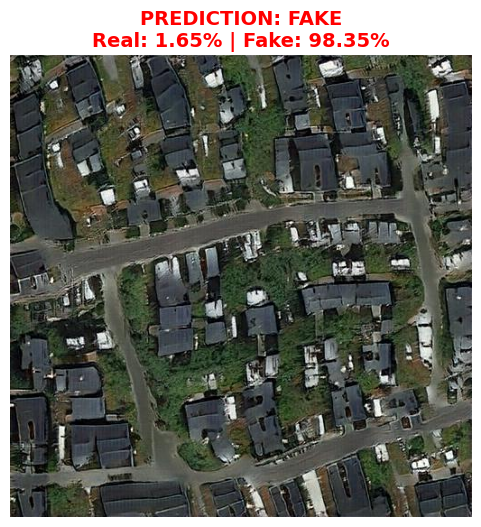

In [20]:
test_single_image("000000042.jpg")

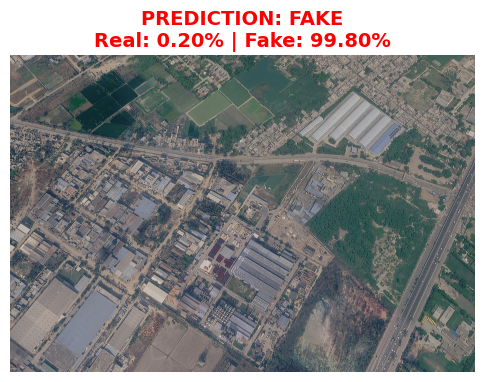

In [21]:
test_single_image("urban_6.jpg")

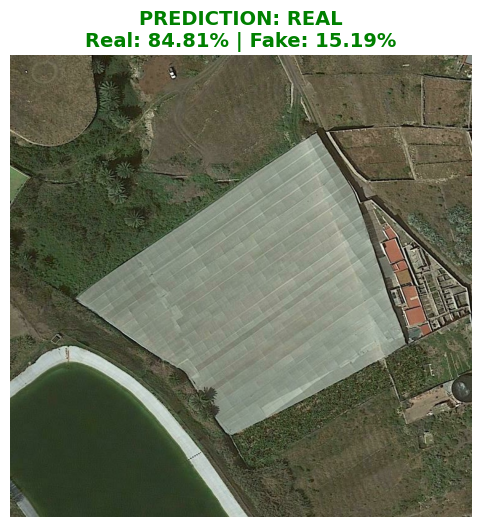

In [23]:
test_single_image("000000007.jpg")

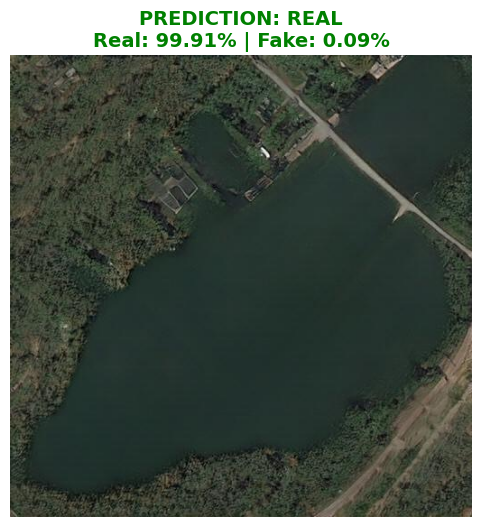

In [24]:
test_single_image("000000044.jpg")

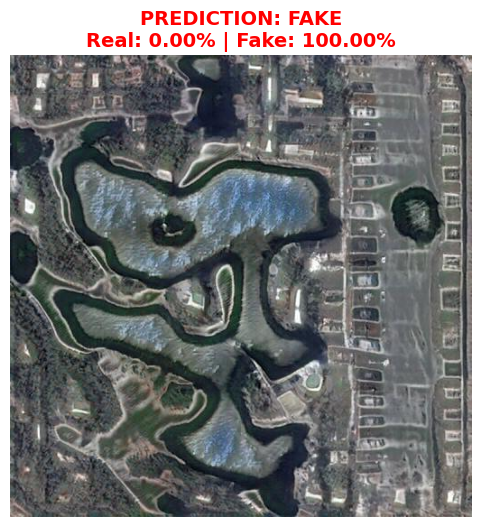

In [25]:
test_single_image("000000005.jpg")

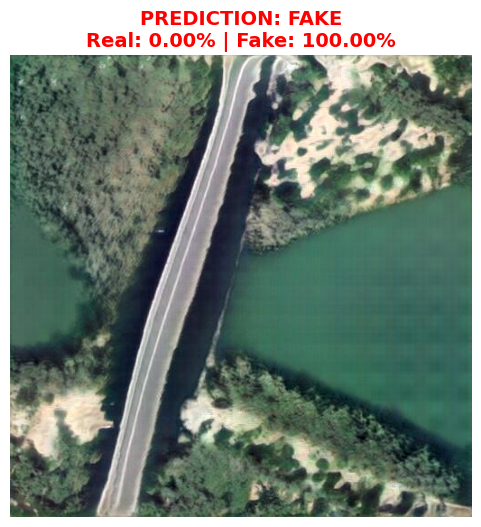

In [26]:
test_single_image("000000000.jpg")